# Exercise 2 - BERT
_By Abigail Hayes. Based on content by Indira Sen and [AI for Humanists](https://aiforhumanists.com/tutorials/)._

In this exercise you will work with [HuggingFace](https://huggingface.co/) and specifically [BERT](https://huggingface.co/docs/transformers/en/model_doc/bert) models. We will look at finetuning models and using pretrained versions. 

There will then be the opportunity to try further variants yourself.

## Setup

First we will set up our environment and prepare a dataset.

### Environment

If these Python packages are not yet available in your environment, then you should install them.
- numpy - for working with data
- pandas - for data analysis
- sklearn - for machine learning
- torch - for deep learning (instructions [here](https://pytorch.org/))
- transformers - for working with HuggingFace
- accelerate - simplify distributed training

In [1]:
from collections import defaultdict
import pandas as pd

### Download data

We will use the same dataset as last week.

In [2]:
datapath = 'https://raw.githubusercontent.com/leelaylay/TweetSemEval/master/dataset/train/twitter-2013train-A.txt'
data = pd.read_csv(datapath, sep = '\t', names = ['id', 'sentiment', 'text'])
data

,id,sentiment,text
0,264183816548130816,positive,Gas by my house hit $3.39!!!! I\u2019m going t...
1,263405084770172928,negative,Theo Walcott is still shit\u002c watch Rafa an...
2,262163168678248449,negative,its not that I\u2019m a GSP fan\u002c i just h...
3,264249301910310912,negative,Iranian general says Israel\u2019s Iron Dome c...
4,262682041215234048,neutral,Tehran\u002c Mon Amour: Obama Tried to Establi...
...,...,...,...
9679,103158179306807296,positive,RT @MNFootNg It's monday and Monday Night Foot...
9680,103157324096618497,positive,All I know is the road for that Lomardi start ...
9681,100259220338905089,neutral,"All Blue and White fam, we r meeting at Golden..."
9682,104230318525001729,positive,@DariusButler28 Have a great game agaist Tam...


## DistilBERT

We will work with the [DistilBERT](https://huggingface.co/docs/transformers/en/model_doc/distilbert) model. We an download this from HuggingFace.

In [3]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

 We also set some basic configuration settings.

In [4]:
model_name = 'distilbert-base-uncased'
device_name = 'cuda'

# This is the maximum number of tokens in any document; the rest will be truncated.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'output_hf'

### Pre-processing

First, generate the train/test split as we did last week.

In [5]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size = 0.3)

We will also encode the labels as a preprocessing step.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train['sentiment'])
train['labels'] = le.transform(train['sentiment'])
test['labels'] = le.transform(test['sentiment'])

We will be able to look at the transformation of the text for the model to use. Each tweet will be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens.

The tokens will be separated into "word pieces" using the transformers tokenizers ('DistilBertTokenizerFast' in this case to match the DistiBERT model). And some special tokens will also be added such as **CLS** (start token of every tweet) and **SEP** (separator between each sentence {not tweet}).

In [7]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Abigail Hayes\miniconda3\envs\llms_hws25\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abigail Hayes\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Now we can encode our text using the tokenizer.

In [8]:
from datasets import Dataset

train = Dataset.from_pandas(train)
test = Dataset.from_pandas(test)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_train_df = train.map(tokenize_function, batched=True)
tokenized_test_df = test.map(tokenize_function, batched=True)

Map:   0%|          | 0/6778 [00:00<?, ? examples/s]

Map:   0%|          | 0/2906 [00:00<?, ? examples/s]

### Model initialisation

Now we will load the DistilBERT model and specify that it should use the GPU.

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(model_name,
                                                            num_labels=3).to(device_name)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Fine-tuning BERT

As the message above indicates after loading the model, we should fine-tune BERT specifically for the task. We first set some training parameters.

In [10]:
training_args = TrainingArguments(
    num_train_epochs=3,              # total number of training epochs
    output_dir='./results',          # output directory
    report_to='none'
)

Now, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [11]:
from sklearn.metrics import accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {
      'accuracy': acc,
  }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

In [ ]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=tokenized_train_df,    # training dataset
    compute_metrics=compute_metrics      # our custom evaluation function
)

In [13]:
tokenized_train_df

Dataset({
    features: ['id', 'sentiment', 'text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 6778
})

Now to fine-tune! This might take a while...

In [14]:
trainer.train()

Step,Training Loss
500,0.723300
1000,0.544000
1500,0.397300
2000,0.274900
2500,0.199100


TrainOutput(global_step=2544, training_loss=0.4241082863237873, metrics={'train_runtime': 292.9409, 'train_samples_per_second': 69.413, 'train_steps_per_second': 8.684, 'total_flos': 2693640120662016.0, 'train_loss': 0.4241082863237873, 'epoch': 3.0})

Now to save the model, so that next time you can load it directly without fine-tuning again. (If you are working in Colab, then you will also want to download the model to your computer if you want to preserve it.)

In [15]:
trainer.save_model(cached_model_directory_name)

Here is the code for re-loading:

In [ ]:
# model = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

### Evaluation

Now we will evaluate the model performance on the test set. The first step in this is getting the model to predict the labels.

In [24]:
predicted_results = trainer.predict(tokenized_test_df)
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels[0:5]
predicted_label_text = le.inverse_transform(predicted_labels)

The rest of the evaluation will look very similar to last week.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test['sentiment'],
                            predicted_label_text))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       439
           1       0.79      0.80      0.80      1379
           2       0.80      0.76      0.78      1088

    accuracy                           0.77      2906
   macro avg       0.74      0.75      0.74      2906
weighted avg       0.77      0.77      0.77      2906



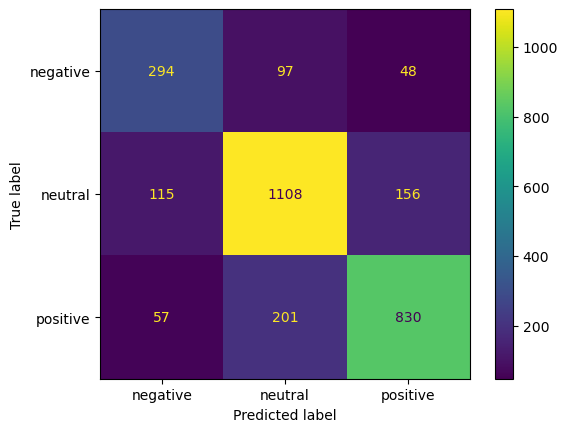

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(test['sentiment'], predicted_label_text)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()

### Examine results

Now that we have some predictions, look at some examples of correctly classified and missclassified tweets. First, the correctly classified:

In [26]:
import random

for _sent, _pred, _text in random.sample(list(zip(test['sentiment'], predicted_label_text, train['text'])), 10):
  if _sent == _pred:
    print('LABEL:', _sent)
    print('TWEET:', _text[:100], '...')
    print()

LABEL: positive
TWEET: Hommage to Gary Carter and the Expos Day tomorrow at RCup: dollar hot dogs\u002c and $8 tix at the 3 ...

LABEL: neutral
TWEET: @RAINN01 is in the running to get a 2012 @GreatNonprofits Top-Rated Award and needs 10 new positive  ...

LABEL: neutral
TWEET: NYSports Rothstein Files: Five Observations From UConn: Monday was the first time I took in a practi ...

LABEL: neutral
TWEET: Big 4 with Kevin\u002c Deniesse\u002c Devine\u002c and Ryan sa kick off ng PBB Teen Edition 4 on Sun ...

LABEL: negative
TWEET: Tennessee is going to kill troy on Saturday! ...

LABEL: neutral
TWEET: Pottstown and Pottsgrove School Districts CLOSED on Tuesday due to the hurricane. ...

LABEL: negative
TWEET: when the best talent is on internship......  \""@temasekpoly: Sony is coming to TP this Friday to lo ...

LABEL: positive
TWEET: COME SUPPORT BALLARD FIELD HOCKEY in the SEMI-FINALS tomorrow at 7:15 at bellarmine! #bruinfam #stud ...

LABEL: positive
TWEET: @courtneyolson12 Courtne

And now the missclassified:

In [29]:
for _sent, _pred, _text in random.sample(list(zip(test['sentiment'], predicted_label_text, train['text'])), 20):
  if _sent != _pred:
    print('TRUE LABEL:', _sent)
    print('PREDICTED LABEL:', _pred)
    print('TWEET:', _text[:100], '...')
    print()

TRUE LABEL: positive
PREDICTED LABEL: neutral
TWEET: Britain may be in for a new bout of flooding in the coming months\u002c the Environment Agency warns ...

TRUE LABEL: positive
PREDICTED LABEL: negative
TWEET: Pushing myself like no tomorrow to study for just a little more - not feeling good about tomorrow\u2 ...



## Task 1 - Using a pretrained model

We have now fine-trained our own model, but this is generally not necessary since other people have already fine-tuned models for the same task. This task will take you through the process step by step.

### Task 1a - Sentiment prediction

First we will setup the [selected model](https://huggingface.co/lxyuan/distilbert-base-multilingual-cased-sentiments-student).

In [30]:
from transformers import pipeline

distilled_student_sentiment_classifier = pipeline(
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    return_all_scores=True
)

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

c:\Users\Abigail Hayes\miniconda3\envs\llms_hws25\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abigail Hayes\.cache\huggingface\hub\models--lxyuan--distilbert-base-multilingual-cased-sentiments-student. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0
c:\Users\Abigail Hayes\miniconda3\envs\llms_hws25\Lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


What advantages does this model offer over the model we pretrained ourselves? What are the potential disadvantages?

_Answer here..._

This model has been trained on a much larger dataset. It is also multilingual so should cope better with text in other languages.

However, we have less control over which data was used for training and it may not be trained specifically to the task.

Use this model to predict the sentiment of the two tweets below:

In [ ]:
anti_biden_tweet = "Ugh, this was true yesterday and it's also true now: Biden is bad for the country"
pro_biden_tweet = "I'm voting for Biden 100%"

labels = distilled_student_sentiment_classifier ([anti_biden_tweet, pro_biden_tweet])

final_labels = []
for label in labels:
  label_df = pd.DataFrame(label).sort_values(by = ['score'], ascending = False).reset_index()
  print(label_df)
  print()
  final_labels.append(label_df['label'][0])

final_labels

   index     label     score
0      2  negative  0.823385
1      0  positive  0.097707
2      1   neutral  0.078907

   index     label     score
0      0  positive  0.591868
1      2  negative  0.223359
2      1   neutral  0.184773



['negative', 'positive']

Now create a list with predictions for all of the test dataset.

In [ ]:
from tqdm import tqdm

labels = []
for text in tqdm(test['text']):
  labels.append(distilled_student_sentiment_classifier(text)[0])

100%|██████████| 2906/2906 [00:11<00:00, 263.91it/s]


In [35]:
final_labels = []
for label in labels:
  label_df = pd.DataFrame(label).sort_values(by = ['score'], ascending = False).reset_index()
  final_labels.append(label_df['label'][0])

In [ ]:
def predict_labels(test_text):
    labels = []
    for text in tqdm(test_text):
        labels.append(distilled_student_sentiment_classifier(text)[0])    

    final_labels = []
    for label in labels:
        label_df = pd.DataFrame(label).sort_values(by = ['score'], ascending = False).reset_index()
        final_labels.append(label_df['label'][0])      
    return final_labels     

What is the performance for this model?

In [36]:
print(classification_report(test['sentiment'], final_labels))

              precision    recall  f1-score   support

    negative       0.41      0.77      0.54       439
     neutral       0.40      0.01      0.03      1379
    positive       0.46      0.87      0.60      1088

    accuracy                           0.45      2906
   macro avg       0.43      0.55      0.39      2906
weighted avg       0.43      0.45      0.32      2906



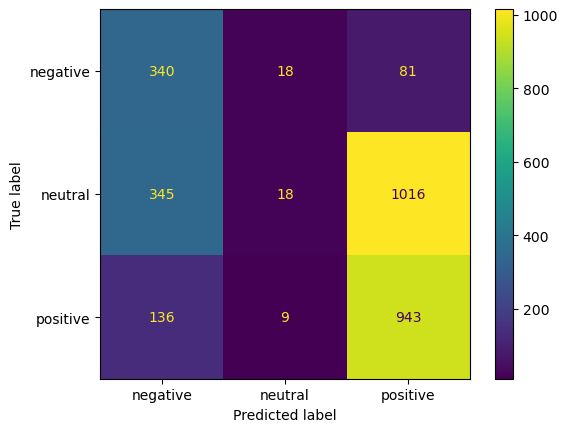

In [37]:
cm = confusion_matrix(test['sentiment'], final_labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()

## Task 1b - Topic classification

Now we will try a slightly different task. For topic classification, we need a model that has been fine-tuned for this task.

In [38]:
# Load a multi-class classification pipeline - if the model runs on CPU, comment out "device"
classifier = pipeline("text-classification", model="classla/multilingual-IPTC-news-topic-classifier", device=0, max_length=512, truncation=True)

config.json: 0.00B [00:00, ?B/s]

c:\Users\Abigail Hayes\miniconda3\envs\llms_hws25\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abigail Hayes\.cache\huggingface\hub\models--classla--multilingual-IPTC-news-topic-classifier. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0


Classify these example texts:

In [39]:
texts = [
    "Ugh, this was true yesterday and it's also true now: Biden is bad for the country",
    "It's really scary with the covid numbers increasing so much",
    "Diese Asylanten nehmen weider unsere Arbeitsplätzen",
    "Apoiadores de Bolsonaro ocupam senado federal",
    "Sao Paulo vence Palmeiras em jogo apertado",
    "Лавров та глава МЗС Туреччини обговорили переговори про війну в Україні"
    ]

# Classify the texts
results = classifier(texts)

# Output the results
for result in results:
    print(result)

{'label': 'politics', 'score': 0.9973794221878052}
{'label': 'health', 'score': 0.3499413728713989}
{'label': 'labour', 'score': 0.9535834789276123}
{'label': 'politics', 'score': 0.997032642364502}
{'label': 'sport', 'score': 0.9828656315803528}
{'label': 'conflict, war and peace', 'score': 0.9601569175720215}


Now try the same with a sample from our dataset.

In [40]:
data_sample = data.sample(100)
data_sample

,id,sentiment,text
6017,111991323975888899,negative,Well at least my Steelers didn't play tonight
2094,250265462385037312,neutral,Make sure everyone comes out to our first open...
5936,110540813716570112,positive,"@Rastas4Jesus09 Droid Bionic, this Thursday. N..."
6870,102752363693080577,positive,"On September 3 at the Pride Park Ground, Derby..."
346,261556214624837632,neutral,I\u2019m far too stressed about finishing this...
...,...,...,...
6880,100046146361245697,neutral,Have seen 4 deer in Dexter so far tonight @hal...
4606,263506900858060800,positive,STAR wishes all the #students at @BrandeisU a ...
2526,264121431720345600,neutral,Raymond\u2019s been busy and we have homemade ...
6523,100486632314109952,neutral,Woods down to 30th in world rankings: Tiger Wo...


In [41]:
tweets = list(data_sample['text'].values)
tweets[:5]

["Well at least my Steelers didn't play tonight",
 'Make sure everyone comes out to our first opener practice tomorrow at 6:30 at the Murphy Center in dance studio B!!!',
 '@Rastas4Jesus09 Droid Bionic, this Thursday. Never thought the day would come.',
 'On September 3 at the Pride Park Ground, Derby, UK. There will be India vs Pakistan football match. That will surely be worth watching!',
 'I\\u2019m far too stressed about finishing this essay for tomorrow\\u002c so I shall minimise it and play Temple Run. #ProblemSolved']

In [42]:
results = classifier(tweets)

In [43]:
data_sample['predicted_topic'] = [i['label'] for i in results]
data_sample['predicted_prob'] = [i['score'] for i in results]
data_sample

,id,sentiment,text,predicted_topic,predicted_prob
6017,111991323975888899,negative,Well at least my Steelers didn't play tonight,sport,0.985033
2094,250265462385037312,neutral,Make sure everyone comes out to our first open...,"arts, culture, entertainment and media",0.997366
5936,110540813716570112,positive,"@Rastas4Jesus09 Droid Bionic, this Thursday. N...","arts, culture, entertainment and media",0.649334
6870,102752363693080577,positive,"On September 3 at the Pride Park Ground, Derby...",sport,0.998499
346,261556214624837632,neutral,I\u2019m far too stressed about finishing this...,education,0.978043
...,...,...,...,...,...
6880,100046146361245697,neutral,Have seen 4 deer in Dexter so far tonight @hal...,lifestyle and leisure,0.708961
4606,263506900858060800,positive,STAR wishes all the #students at @BrandeisU a ...,education,0.996359
2526,264121431720345600,neutral,Raymond\u2019s been busy and we have homemade ...,lifestyle and leisure,0.830511
6523,100486632314109952,neutral,Woods down to 30th in world rankings: Tiger Wo...,sport,0.996901
